In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

adata = sc.read_h5ad('/Volumes/seq_epiprod02/etorlait/p16/Published_Data/Gray_et_al_2022/Remap_VersionC_Gtf_Terra/Output_Cumulus/LowGeneMin.unknown-rna.h5ad')
#adata=sc.read('/Volumes/seq_epiprod02/etorlait/p16/Published_Data/Gray_et_al_2022/Remap_VersionC_Gtf_Terra
#etorlait/p16/Published_Data/Gray_et_al_2022/Remap_VersionC_Gtf_Terra

In [2]:
adata

AnnData object with n_obs × n_vars = 554068 × 39212
    obs: 'n_genes', 'n_counts', 'Channel', 'percent_mito', 'scale', 'louvain_labels'
    var: 'featureid', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'mean', 'var', 'hvf_loess', 'hvf_rank'
    uns: 'Channels', 'PCs', 'W_pca', 'df_qcplot', 'genome', 'louvain_resolution', 'modality', 'norm_count', 'pca', 'pca_features', 'pca_knn_distances', 'pca_knn_indices', 'scale.data', 'scale.data.rownames', 'stdzn_max_value', 'stdzn_mean', 'stdzn_std'
    obsm: 'X_pca', 'X_umap'
    varm: 'de_res'

In [3]:
#select_genes=['CDKN2A_p14_ex1','CDKN2A_p16_ex1']
df=adata[:,adata.var.index.isin(['CDKN2A_p14_ex1','CDKN2A_p16_ex1','CDKN2A_p14_p16'])].to_df()

In [4]:
df

featurekey,CDKN2A_p16_ex1,CDKN2A_p14_ex1,CDKN2A_p14_p16
barcodekey,,,
PM_A-AAACCTGAGAAACCGC,0.0,0.0,0.0
PM_A-AAACCTGAGAAACGAG,0.0,0.0,0.0
PM_A-AAACCTGAGAACAACT,0.0,0.0,0.0
PM_A-AAACCTGAGAAGGTGA,0.0,0.0,0.0
PM_A-AAACCTGAGACACGAC,0.0,0.0,0.0
...,...,...,...
RM_D-TTTGTCATCTAACGGT,0.0,0.0,0.0
RM_D-TTTGTCATCTCAACTT,0.0,0.0,0.0
RM_D-TTTGTCATCTGATACG,0.0,0.0,0.0


In [5]:
df_dialup = pd.read_csv("dialup_ratios.csv", index_col=0)

In [6]:
# Extract sample IDs from df (AnnData-derived expression data)
df_sample_ids = df.index.str.split('-').str[0].unique()

# Extract sample IDs from dialup_df (Dial-up ratio data)
dialup_sample_ids = df_dialup.index.str.split('_').str[0].unique()


In [7]:
sample_mapping = {
    "RM-A": "WT-A", "PM-G": "BRCA2-A", "PM-A": "BRCA1-C", "PM-C": "BRCA1-D",
    "PM-K": "BRCA2-B", "PM-I": "BRCA2-C", "PM-J": "BRCA2-D", "RM-D": "WT-C",
    "RM-C": "WT-D", "PM-F": "BRCA1-H", "PM-L": "BRCA2-E"
}

In [22]:
# Extract barcode prefix as sample ID in dialup_df
df_dialup["Sample"] = df_dialup.index.str.split("-").str[0]

# Map sample names to match AnnData
mapped_samples = df_dialup["Sample"].map(sample_mapping).dropna()

df_dialup["Mapped_Sample"] = df_dialup["Sample"].map(sample_mapping)

# Ensure 'Mapped_Sample' column exists and use it for grouping
percent_expressing = df_dialup.groupby("Mapped_Sample", group_keys=False).apply(
    lambda x: (x[["dialup_p16_ratio_nCounts", "dialup_p14_ratio_nCounts"]] > 0).mean() * 100
).reset_index()

# Reshape data for plotting
df_melted = percent_expressing.melt(id_vars=["Mapped_Sample"],
                                    var_name="Dialup Type",
                                    value_name="Percentage Expressing")

# Create bar plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_melted, x="Mapped_Sample", y="Percentage Expressing",
                 hue="Dialup Type", errorbar="sd")

plt.xticks(rotation=45, ha="right")
plt.ylabel("Percentage of Expressing Cells")
plt.xlabel("Mapped Sample")
plt.title("Comparison of Dialup Expression by Sample")
plt.legend(title="Dialup Type")

plt.show()


ValueError: cannot insert Mapped_Sample, already exists

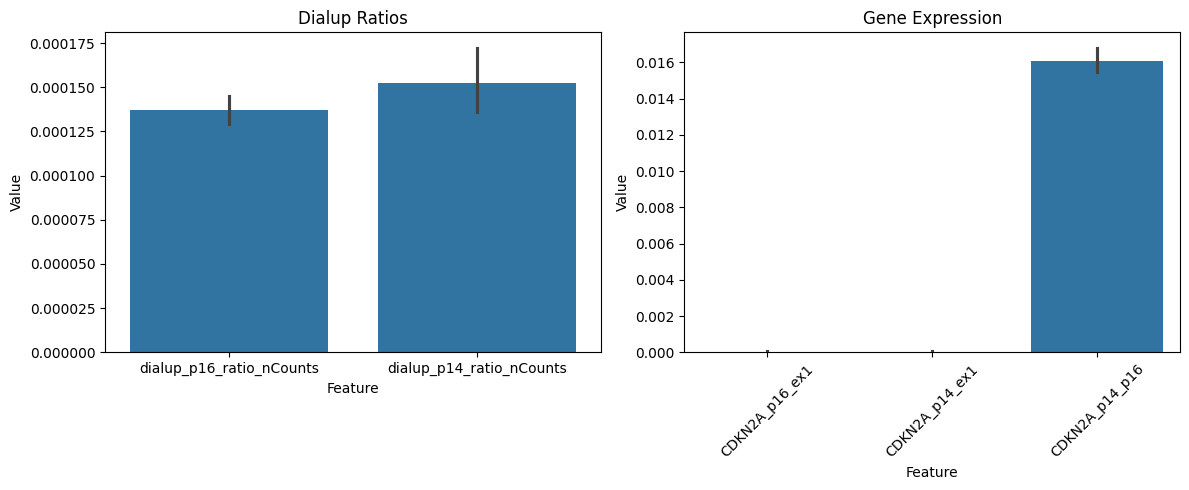

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Melt data separately for easier plotting
df_ratios_melted = df_ratios_read.melt(var_name="Feature", value_name="Value")
df_expression_melted = df_expression.melt(var_name="Feature", value_name="Value")

# Barplot (mean comparison)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=df_ratios_melted, x="Feature", y="Value", ax=axes[0])
axes[0].set_title("Dialup Ratios")

sns.barplot(data=df_expression_melted, x="Feature", y="Value", ax=axes[1])
axes[1].set_title("Gene Expression")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


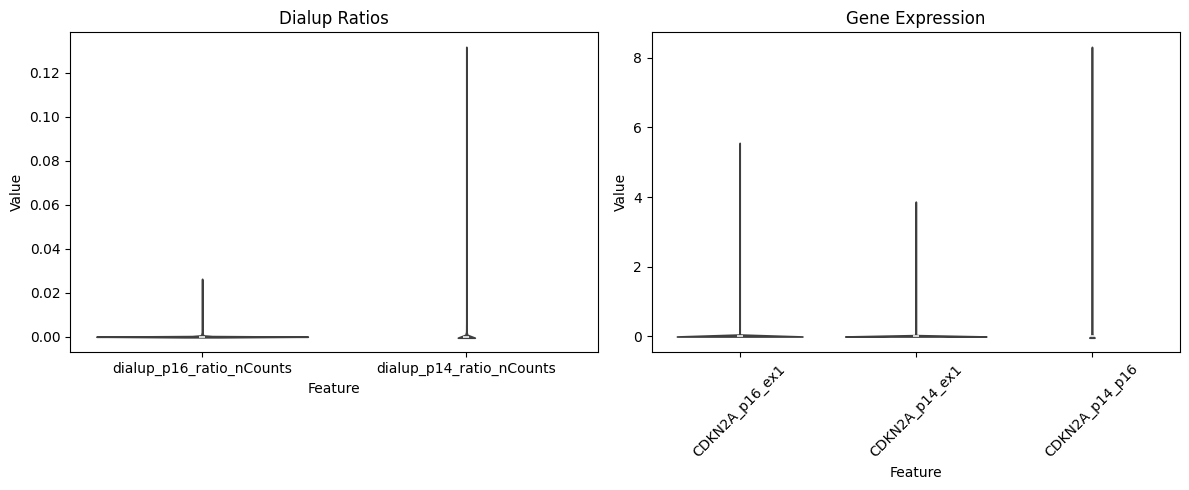

In [12]:
# Violin plot for distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.violinplot(data=df_ratios_melted, x="Feature", y="Value", ax=axes[0])
axes[0].set_title("Dialup Ratios")

sns.violinplot(data=df_expression_melted, x="Feature", y="Value", ax=axes[1])
axes[1].set_title("Gene Expression")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
